# Bloch Neural ODE / PINN Training Pipeline

This notebook combines the project code into a single executable pipeline: simulator, dataset creation, model definitions (Neural ODE RK4, GRU, PINN), training loops, and inference utilities. Code is included largely verbatim from the original files with comments preserved.

Usage notes:
- Run cells in order.
- You may need to install dependencies: `torch`, `numpy`, `matplotlib`, `tqdm`, and optionally `torchdiffeq` for the adaptive ODE model.

In [12]:
 # Setup Code
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()  # notebook placed at repo root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

Project root: C:\Users\shore\Documents\MAT292 Project\Bloch-Equations-Modelling-Project


In [13]:
# Bloch equation simulator for MRI applications, adapted
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Optional, Callable
import json


@dataclass # class that just holds data
class Isochromat: # spin packet: group of spins that are @ same loc and experience same B field.
    """Represents a single isochromat (spin packet) with position and magnetization"""
    M: np.ndarray  # Magnetization vector [Mx, My, Mz] (current magnetization vector of packet)
    pos: np.ndarray  # Position [x, y, z] (spatial position of packet, used in gradient sim.)
    dB0: float = 0.0  # Field offset (field inhomogeneity. irl, B0 isn't uniform & dB0 is small constant 
                      # offset. primary cause of signal decay.)
    T1: float = np.inf  # Longitudinal relaxation time (how quickly component along main field M_z recovers to o.g. M_0
                        # small T_1 => fast recovery)
    T2: float = np.inf  # Transverse relaxation time (how quickly M_x and M_y decay to 0 b/c of random microscopic spin
                        # interactions.)
    M0: float = 1.0  # Equilibrium magnetization (fully relaxed magnetization vector in +z axis. )


class BlochSimulator:
    
    def __init__(self, gamma: float = 1.0, B0: float = 2.0):
        """
            gamma: Gyromagnetic ratio (default normalized to 1) (omega = gamma * B)
            B0: Main magnetic field strength
        """
        self.gamma = gamma 
        self.B0 = B0 # strength of main static B field
        self.isochromats: List[Isochromat] = [] # list of all spin packets
        self.time = 0.0 # current time ig
        self.history = [] # snapshot of system state at every time step
        
        # Field parameters
        self.B1 = 0.0  # RF field amplitude
        self.B1_freq = 0.0  # RF frequency
        self.phi1 = 0.0  # RF phase
        self.Gx = 0.0  # X gradient
        self.Gy = 0.0  # Y gradient
        
        # Pulse parameters
        self.RF_active = False
        self.RF_time_left = 0.0
        self.RF_area_left = 0.0
        self.RF_func: Optional[Callable] = None
        
    def add_isochromat(self, M: np.ndarray, pos: np.ndarray = np.array([0, 0, 0]),
                       dB0: float = 0.0, T1: float = np.inf, T2: float = np.inf):
        # Add an isochromat to the simulation
        iso = Isochromat(M=M.copy(), pos=pos.copy(), dB0=dB0, T1=T1, T2=T2)
        self.isochromats.append(iso)
        
    def setup_single_spin(self):
        # Setup a single perfect spin at origin w/o relaxation equilibrium 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]))
        
    def setup_inhomogeneous(self, n_spins: int = 9, spread: float = 0.3):
        # Setup multiple spins with field inhomogeneity. Multiple spins @ same location but diff. dBO values. Simulate T2 decay
        # where diff spins precess @ diff speeds and fan out in xy plane (causing signal decay).
        self.isochromats.clear()
        for i in range(n_spins):
            dB0 = (i - (n_spins-1)/2) / (n_spins/6) * spread
            self.add_isochromat(np.array([0, 0, 1]), dB0=dB0)
            
    def setup_spatial_line(self, n_spins: int = 21, spacing: float = 0.4):
        # Setup spins along a line (x-axis) for gradient testing. Show if G_x (x gradient) works.
        self.isochromats.clear()
        for i in range(n_spins):
            x_pos = (i - (n_spins-1)/2) * spacing
            self.add_isochromat(
                np.array([0, 0, 1]), 
                pos=np.array([x_pos, 0, 0])
            )
            
    def setup_relaxation(self, T1: float = 5.0, T2: float = 3.0):
        # Setup a single spin with relaxation (finite T1, T2 values). 
        self.isochromats.clear()
        self.add_isochromat(np.array([0, 0, 1]), T1=T1, T2=T2)
        
    def RF_pulse_rect(self, angle: float, phase: float, B1_amplitude: float = 4.0):
        """
        Apply rectangular RF pulse

            angle: Flip angle in radians
            phase: RF phase in radians
            B1_amplitude: RF field strength
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        duration = angle / (self.gamma * B1_amplitude)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = self._RF_const # which function step method shoudl call to get B1 field value @ some time.
        
    def RF_pulse_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                      n_lobes: int = 4):
        # a sinc-shaped RF pulse
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase
        
        # Sinc pulse is longer to maintain same area
        sinc_correction = 0.22570583339507  # Si(2π)/(2π) for 4-lobe sinc
        duration = angle / (self.gamma * B1_amplitude * sinc_correction)
        
        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_sinc(t, duration, n_lobes)

    # RF_const and RF_sinc actually calculate B1 vector at time t.  
    def _RF_const(self, t: float) -> Tuple[np.ndarray, float]:
        # Constant (rectangular) RF pulse shape
        phase = self.B1_freq * t - self.phi1
        B1_vec = np.array([
            self.B1 * np.cos(phase),
            -self.B1 * np.sin(phase),
            0.0
        ])
        return B1_vec, self.B1
    
    def _RF_sinc(self, t: float, duration: float, n_lobes: int) -> Tuple[np.ndarray, float]:
        # Sinc RF pulse shape
        phase = self.B1_freq * t - self.phi1
        sinc_arg = n_lobes * np.pi * (t/duration - 0.5)
        
        if abs(sinc_arg) > 0.01:
            envelope = self.B1 * np.sin(sinc_arg) / sinc_arg
        else:
            envelope = self.B1
            
        B1_vec = np.array([
            envelope * np.cos(phase),
            -envelope * np.sin(phase),
            0.0
        ])
        return B1_vec, envelope
    
    import numpy as np

    # ----------------------- Helpers (inside the class) -----------------------

    def _duration_from_envelope_avg(self, angle, B1_peak, env_of_tau, n=4096):
        """
        Numerically compute the duration that yields the requested flip angle.

        We assume an envelope defined on tau in [0,1] with peak 1.0:
            B1(t) = B1_peak * env_of_tau(t / duration)
        => area = ∫ B1 dt = B1_peak * duration * ∫_0^1 env(τ) dτ
        Flip angle: angle = gamma * area

        So: duration = angle / (gamma * B1_peak * avg_env),
            where avg_env = ∫_0^1 env(τ) dτ
        """
        tau = np.linspace(0.0, 1.0, n, endpoint=False) + 0.5 / n
        env_vals = env_of_tau(tau)
        avg_env = np.trapz(env_vals, tau)  # integral over [0,1]
        avg_env = float(max(avg_env, 1e-12))  # guard
        return angle / (self.gamma * B1_peak * avg_env)

    # -------------------- 1) Gaussian pulse (RF_pulse_gaussian) --------------------

    def RF_pulse_gaussian(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        sigma_frac: float = 0.20):
        """
        Apply a Gaussian-envelope RF pulse with flip-angle normalization.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (envelope peak = 1.0 -> peak field = B1_amplitude)
        sigma_frac: controls width of the Gaussian relative to duration
                    (σ in units of half-duration; 0.2 is a common smooth choice)
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # envelope on τ ∈ [0,1], centered at 0.5
        def env_of_tau(tau):
            # convert sigma_frac (fraction of half-duration) to σ on τ-domain
            # half-duration in τ is 0.5, so σ_τ = sigma_frac / 0.5
            sigma_tau = sigma_frac / 0.5
            return np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_gaussian(t, duration, sigma_frac)

    def _RF_gaussian(self, t: float, duration: float, sigma_frac: float):
        """Return (B1_vec, envelope) for Gaussian envelope at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        sigma_tau = sigma_frac / 0.5
        env = float(np.exp(-0.5 * ((tau - 0.5) / sigma_tau) ** 2))

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # --------------- 2) Hamming-windowed sinc (RF_pulse_windowed_sinc) ---------------

    def RF_pulse_windowed_sinc(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                            n_lobes: int = 4):
        """
        Apply a Hamming-windowed sinc RF pulse (cleaner spectrum than plain sinc).

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: peak B1 (after windowing; peak env is normalized to 1)
        n_lobes: number of lobes on each side of the center
        """
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        # Continuous-time Hamming window on τ ∈ [0,1]
        def window_hamming(tau):
            return 0.54 - 0.46 * np.cos(2 * np.pi * tau)

        def env_of_tau(tau):
            # Map τ∈[0,1] to x∈[-n_lobes, n_lobes]
            x = (tau - 0.5) * 2.0 * n_lobes
            sinc = np.sinc(x)  # np.sinc uses sin(πx)/(πx); OK up to scale
            env = sinc * window_hamming(tau)
            # normalize to peak 1.0 so B1_amplitude is actual peak
            peak = np.max(np.abs(env))
            return env / (peak + 1e-12)

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_windowed_sinc(t, duration, n_lobes)

    def _RF_windowed_sinc(self, t: float, duration: float, n_lobes: int):
        """Return (B1_vec, envelope) for Hamming-windowed sinc at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        x = (tau - 0.5) * 2.0 * n_lobes
        sinc = np.sinc(x)
        window = 0.54 - 0.46 * np.cos(2 * np.pi * tau)
        env = sinc * window
        env /= (np.max([abs(env), 1e-12]))  # tiny guard if called at boundaries

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env

    # ------------------ 3) Trapezoidal (ramps) (RF_pulse_trapezoid) ------------------

    def RF_pulse_trapezoid(self, angle: float, phase: float, B1_amplitude: float = 4.0,
                        ramp_frac: float = 0.10):
        """
        Apply a trapezoidal RF pulse with linear rise/fall ramps.

        angle: flip angle [rad]
        phase: RF carrier phase [rad]
        B1_amplitude: plateau peak
        ramp_frac: fraction of the duration used for each ramp (0–0.5)
        """
        ramp_frac = float(np.clip(ramp_frac, 0.0, 0.49))
        self.B1 = B1_amplitude
        self.B1_freq = self.gamma * self.B0
        self.phi1 = phase

        def env_of_tau(tau):
            # piecewise linear: rise -> flat -> fall on τ∈[0,1]
            r = ramp_frac
            env = np.empty_like(tau)
            # rise
            rise = tau < r
            env[rise] = tau[rise] / max(r, 1e-12)
            # flat
            flat = (tau >= r) & (tau <= 1.0 - r)
            env[flat] = 1.0
            # fall
            fall = tau > 1.0 - r
            env[fall] = (1.0 - tau[fall]) / max(r, 1e-12)
            return env

        duration = self._duration_from_envelope_avg(angle, B1_amplitude, env_of_tau)

        self.RF_active = True
        self.RF_time_left = duration
        self.RF_area_left = angle
        self.RF_func = lambda t: self._RF_trapezoid(t, duration, ramp_frac)

    def _RF_trapezoid(self, t: float, duration: float, ramp_frac: float):
        """Return (B1_vec, envelope) for a trapezoid at time t."""
        tau = np.clip(t / duration, 0.0, 1.0)
        r = ramp_frac
        if tau < r:
            env = tau / max(r, 1e-12)
        elif tau <= 1.0 - r:
            env = 1.0
        else:
            env = (1.0 - tau) / max(r, 1e-12)

        phase = self.B1_freq * t - self.phi1
        B1x = self.B1 * env * np.cos(phase)
        B1y = -self.B1 * env * np.sin(phase)
        B1_vec = np.array([B1x, B1y, 0.0], dtype=float)
        return B1_vec, self.B1 * env



    def random_fourier_pulse(T: int, dt: float, A: float, n_terms: int = 5):
        """
        Generate a random composite pulse as a sum of sinusoids.

        Parameters
        ----------
        T : int
            Number of samples.
        dt : float
            Time step (seconds).
        A : float
            Overall amplitude scaling.
        n_terms : int
            Number of random harmonic components to sum.

        Returns
        -------
        np.ndarray
            Random, smooth RF envelope normalized to amplitude A.
        """
        t = np.arange(T) * dt
        y = np.zeros_like(t)
        for _ in range(n_terms):
            f = np.random.uniform(100, 5000)  # random frequency in Hz
            phi = np.random.uniform(0, 2 * np.pi)
            y += np.sin(2 * np.pi * f * t + phi)
        y /= np.max(np.abs(y)) + 1e-8
        return (A * y).astype(np.float32)



    def apply_gradient(self, phase_diff: float, direction_angle: float = 0.0):
        """Apply gradient pulse"""
        grad_scale = 11  # From o.g. code
        duration = 1.0  # seconds
        area = phase_diff * grad_scale / self.gamma
        
        self.Gx = np.cos(direction_angle) * area / duration
        self.Gy = np.sin(direction_angle) * area / duration
        
    def step(self, dt: float):
        """
        Evolve the system by one time step using Bloch equations

            dt: Time step in seconds
        """
        self.time += dt
        
        # Get RF field
        if self.RF_active and self.RF_time_left > 0: # check if RF is on and time remaining
            B1_vec, envelope = self.RF_func(self.time) # get B1 vector
            dArea = dt * self.gamma * envelope
            
            if self.RF_time_left < dt:
                # End of pulse (adjust to match target angle)
                B1_vec *= self.RF_area_left / dArea
                self.RF_active = False
                self.RF_time_left = 0
                self.B1 = 0
            else:
                self.RF_area_left -= dArea
                self.RF_time_left -= dt
        else: # no B1 vec if no RF
            B1_vec = np.array([0, 0, 0])
            self.RF_active = False
            
        # Update each isochromat
        for iso in self.isochromats:
            # Total field including gradients and offsets. total B field each iso feels at this instant.
            grad_scale = 11  # From o.g. code
            detuning = iso.dB0 + (self.Gx * iso.pos[0] + self.Gy * iso.pos[1]) / grad_scale
            # z field detuning is sum of spin's personal offset and gradient fields.  multiplications mean "if G_x grad on, 
            # field depends on x_position)"
            B_total = B1_vec + np.array([0, 0, self.B0 + detuning])
            
            # Precession (M x B term) (Rotation due to B field)
            B_mag = np.linalg.norm(B_total)
            if B_mag > 1e-10:
                rotation_angle = -B_mag * dt * self.gamma
                rotation_axis = B_total / B_mag
                
                # Rodrigues' rotation formula
                K = np.array([
                    [0, -rotation_axis[2], rotation_axis[1]],
                    [rotation_axis[2], 0, -rotation_axis[0]],
                    [-rotation_axis[1], rotation_axis[0], 0]
                ])
                R = np.eye(3) + np.sin(rotation_angle) * K + \
                    (1 - np.cos(rotation_angle)) * K @ K
                iso.M = R @ iso.M # isochromat's magnetizatoin vector updated by matrix-multiplying it by rotation
                # matrix R to precess vector.
            
            # Relaxation (T1, T2 terms)
            if np.isfinite(iso.T1) or np.isfinite(iso.T2):
                f1 = np.exp(-dt / iso.T1) if np.isfinite(iso.T1) else 1.0 # exponential decay factor for M_z in time dt
                f2 = np.exp(-dt / iso.T2) if np.isfinite(iso.T2) else 1.0 # exponential decay factor for M_x and M_y in time dt.
                
                iso.M[0] *= f2 # Mx decays toward 0
                iso.M[1] *= f2 # My decays toward 0
                iso.M[2] = iso.M[2] * f1 + (1 - f1) * iso.M0 # analytic solution for T1 relaxation. M_z decays toward 0 w/
                # f1 and (at teh same time) grows back towards M0 (equil)
        
        # Store history
        self._record_state() # append state of all isochromats to self.history
        
    def _record_state(self):
        """Record current state for history"""
        state = {
            'time': self.time,
            'magnetization': np.array([iso.M.copy() for iso in self.isochromats]),
            'B1': self.B1,
            'RF_active': self.RF_active
        }
        self.history.append(state)
        
    def get_total_magnetization(self) -> np.ndarray:
        # Get total magnetization vector
        return np.sum([iso.M for iso in self.isochromats], axis=0)
    
    def get_transverse_magnetization(self) -> float:
        # Get magnitude of transverse magnetization
        M_total = self.get_total_magnetization()
        return np.sqrt(M_total[0]**2 + M_total[1]**2)
    
    def simulate_sequence(self, duration: float, dt: float = 0.01):
        """
        Run simulation for specified duration

            duration: Total simulation time
            dt: Time step
        """
        steps = int(duration / dt)
        for _ in range(steps):
            self.step(dt)
            
    def reset(self):
        # Reset simulation
        self.time = 0.0
        self.history.clear()
        for iso in self.isochromats:
            iso.M = np.array([0, 0, iso.M0])


In [14]:
class BlochVisualizer:
    # Visualization for Bloch simulation
    
    @staticmethod
    def plot_magnetization_trajectory(simulator: BlochSimulator, figsize=(12, 4)):
        # Plot Mx, My, Mz over time. Calculates total magnetizaiotn by summing M vectors of all isochromats
        # at each time step.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = [state['time'] for state in simulator.history]
        M_total = np.array([
            np.sum(state['magnetization'], axis=0) / len(simulator.isochromats)
            for state in simulator.history
        ])
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        axes[0].plot(times, M_total[:, 0], 'r-', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Mx')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_title('X Magnetization')
        
        axes[1].plot(times, M_total[:, 1], 'g-', linewidth=2)
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('My')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_title('Y Magnetization')
        
        axes[2].plot(times, M_total[:, 2], 'b-', linewidth=2)
        axes[2].set_xlabel('Time (s)')
        axes[2].set_ylabel('Mz')
        axes[2].grid(True, alpha=0.3)
        axes[2].set_title('Z Magnetization')
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_bloch_sphere(simulator: BlochSimulator, frame_idx: int = -1):
        # Plot magnetization vectors on Bloch sphere. Default picks last time step. Draw M vector for each isochromat.
        # use for dephasing visual. (run setup_inhomo and vectors start aligned and then fan out across xy plane)
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        # Draw sphere
        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = np.outer(np.cos(u), np.sin(v))
        y = np.outer(np.sin(u), np.sin(v))
        z = np.outer(np.ones(np.size(u)), np.cos(v))
        ax.plot_surface(x, y, z, alpha=0.1, color='lightblue')
        
        # Draw axes
        ax.plot([0, 1.3], [0, 0], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 1.3], [0, 0], 'k-', linewidth=2, alpha=0.3)
        ax.plot([0, 0], [0, 0], [0, 1.3], 'k-', linewidth=2, alpha=0.3)
        ax.text(1.4, 0, 0, 'X', fontsize=14)
        ax.text(0, 1.4, 0, 'Y', fontsize=14)
        ax.text(0, 0, 1.4, 'Z', fontsize=14)
        
        # Plot magnetization vectors
        if simulator.history:
            state = simulator.history[frame_idx]
            for M in state['magnetization']:
                ax.quiver(0, 0, 0, M[0], M[1], M[2],
                         arrow_length_ratio=0.1, linewidth=2, color='red')
        
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.set_zlim([-1.2, 1.2])
        ax.set_xlabel('Mx')
        ax.set_ylabel('My')
        ax.set_zlabel('Mz')
        ax.set_title(f'Bloch Sphere at t={simulator.history[frame_idx]["time"]:.2f}s')
        
        return fig
    
    @staticmethod
    def plot_fid_spectrum(simulator: BlochSimulator):
        # Plot FID signal and its spectrum. simulates what MRI/NMR scanner actually measures.
        if not simulator.history:
            print("No simulation data to plot")
            return
            
        times = np.array([state['time'] for state in simulator.history])
        M_total = np.array([
            np.sum(state['magnetization'], axis=0)
            for state in simulator.history
        ])
        
        # Complex transverse magnetization (FID)
        signal = M_total[:, 0] + 1j * M_total[:, 1] # scanner's reciever coil picks up oscillating transverse xy magnetization
        # represnted as complex number. time domain signal called free induction decay.
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Time domain (real, im, and mag of signal that decays)
        axes[0].plot(times, signal.real, 'b-', label='Real', linewidth=2)
        axes[0].plot(times, signal.imag, 'r-', label='Imaginary', linewidth=2)
        axes[0].plot(times, np.abs(signal), 'k--', label='Magnitude', linewidth=2)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')
        axes[0].set_title('FID Signal')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Frequency domain (spectrum)
        dt = times[1] - times[0] if len(times) > 1 else 0.01
        spectrum = np.fft.fftshift(np.fft.fft(signal)) # calculates FFT of FID. time to frequency domain.
        freqs = np.fft.fftshift(np.fft.fftfreq(len(signal), dt)) # 0 freq at center
        
        axes[1].plot(freqs, np.abs(spectrum), 'b-', linewidth=2)
        axes[1].set_xlabel('Frequency (Hz)')
        axes[1].set_ylabel('Magnitude')
        axes[1].set_title('Spectrum')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlim([freqs[0], freqs[-1]])
        
        plt.tight_layout()
        return fig

## BlochSim Tester

Quick visual / functional tests for the `BlochSimulator` — adapted from `tests/blochsim_tester.py`. Run these to sanity-check the simulator before dataset generation or training.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- shared helper ----------
def plot_trajectory3d(sim, title=""):
    M = np.array([np.sum(s["magnetization"], axis=0) for s in sim.history])  # (T,3)
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)

    # sphere surface (reference)
    u = np.linspace(0, 2*np.pi, 72)
    v = np.linspace(0, np.pi, 36)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, alpha=0.12, edgecolor="none")

    ax.plot(M[:, 0], M[:, 1], M[:, 2], linewidth=2)
    ax.scatter(M[0, 0], M[0, 1], M[0, 2], s=60, c="g", label="start")
    ax.scatter(M[-1, 0], M[-1, 1], M[-1, 2], s=60, c="r", label="end")
    ax.legend()
    ax.set_xlabel("Mx"); ax.set_ylabel("My"); ax.set_zlabel("Mz")
    lim = 1.2
    ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
    ax.view_init(elev=25, azim=35)
    return fig

# ---------- each case returns a configured-and-run simulator ----------
def case_free_precession():
    """Single spin; precession around +z with no relaxation."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.isochromats[0].M = np.array([1.0, 0.0, 0.0])  # start in xy-plane
    sim.simulate_sequence(duration=5.0, dt=0.001)
    return sim, "Free precession (B0 only)"

def case_90_then_free():
    """90° hard pulse tips M to xy; observe post-pulse precession."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_single_spin()
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=4.0)
    sim.simulate_sequence(duration=3.0, dt=0.0005)
    return sim, "90° pulse → free precession"

def case_relaxation_only():
    """No B0; watch pure T1 recovery and T2 decay toward equilibrium."""
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=7.0, T2=1.0)
    sim.simulate_sequence(duration=8.0, dt=0.005)
    return sim, "Relaxation only (T1/T2)"

def case_relaxation_plus_precession():
    """B0 ≠ 0; spiral back to +z while precessing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.isochromats.clear()
    sim.add_isochromat(M=np.array([1.0, 0.0, 0.0]), T1=9.0, T2=2.0)
    sim.simulate_sequence(duration=10.0, dt=0.005)
    return sim, "Relaxation + precession"

def case_inhomogeneous_dephasing(n=15, spread=0.5):
    """Multiple spins with different dB0; transverse dephasing (T2*)."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=n, spread=spread)
    # tip all into xy to see dephasing clearly
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=5.0)
    sim.simulate_sequence(duration=2.0, dt=0.0005)
    return sim, "Inhomogeneous dephasing (T2*)"

def case_gradient_dephase_rephase():
    """
    Simple 'gradient echo' style: turn on Gx briefly to dephase, then flip sign to rephase.
    NOTE: your apply_gradient sets a steady gradient; we emulate finite pulses by setting Gx,
    simulating, then zeroing / negating it.
    """
    sim = BlochSimulator(gamma=1.0, B0=0.0)
    sim.setup_spatial_line(n_spins=41, spacing=0.15)
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # small delay

    # "Dephase" with +Gx for τ
    sim.Gx = 8.0; sim.Gy = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # "Rephase" with -Gx for τ
    sim.Gx = -8.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)

    # gradients off
    sim.Gx = 0.0
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Gradient echo: dephase → rephase"

def case_spin_echo():
    """Classic Hahn spin echo: 90° — τ — 180° — τ; refocus inhomogeneous dephasing."""
    sim = BlochSimulator(gamma=1.0, B0=2.0)
    sim.setup_inhomogeneous(n_spins=21, spread=0.5)

    # 90° to transverse
    sim.RF_pulse_rect(angle=np.pi/2, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # 180° inversion about x̂ (phase=0)
    sim.RF_pulse_rect(angle=np.pi, phase=0.0, B1_amplitude=6.0)
    sim.simulate_sequence(duration=0.05, dt=0.0005)   # τ

    # observe echo
    sim.simulate_sequence(duration=0.05, dt=0.0005)
    return sim, "Hahn spin echo (90-τ-180-τ)"

def case_sinc_pulse_clean():
    """
    Sinc-shaped RF pulse on a single spin: shows clean 90° flip with visible precession spiral.
    Uses MRI-like B0 with scaled gamma for visualization.
    Extended observation to see many rotations with visible but slow decay.
    """
    # MRI-like parameters
    B0 = 3.0                           # Tesla (typical clinical MRI field)
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (proton gyromagnetic ratio)
    scale_factor = 100.0               # scale gamma for visualization (100× for very clear rotations)
    gamma_scaled = gamma_base * scale_factor
    
    # Setup single spin with tissue-like relaxation
    # Key: use LONG T2 so the spiral stays visible through the entire observation window
    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()
    sim.isochromats[0].T1 = 2.0   # 2000 ms (long relaxation)
    sim.isochromats[0].T2 = 1.5   # 1500 ms (long transverse relaxation — lets spiral be seen for full duration)
    
    # Apply sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)
    
    # Simulate RF pulse and then long observation
    dt = 0.0001  # 0.1 ms timestep
    sim.simulate_sequence(duration=0.01, dt=dt)   # RF pulse (10 ms)
    sim.simulate_sequence(duration=2.0, dt=dt)    # Long free precession (2 s) — full spiral visible
    
    # Diagnostics
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * 2.0  # over the 2s observation window
    print(f"Sinc pulse (clean): B0={B0}T, gamma_scale={scale_factor}× → Larmor ≈ {f_hz:.1f} Hz")
    print(f"Expected rotations in 2.0s: ≈ {rotations:.1f}")
    print(f"T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s — spiral should stay visible for full observation")
    
    return sim, f"Sinc RF (single-spin, extended spiral) — B0={B0}T, T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"


In [16]:
def case_mri_like():
    """
    MRI-like parameters for visualization (scaled gamma):
    - B0 = 3.0 T (typical clinical field)
    - gamma scaled to 2π * 42.577 Hz/T and multiplied by a factor for clearer
      visualization of precession (no physical intent)
    - T1 and T2 set to realistic tissue-like values (seconds)

    Notes:
    - For true physical proton Larmor (42.577 MHz/T) you'd need dt in the
      nanosecond range; here we intentionally scale gamma down for practical
      visualization while keeping B0 at MRI-like value. We further multiply
      gamma by a small factor so you can see many rotations without tiny dt.
    """
    gamma_base = 2.0 * np.pi * 42.577  # rad/s per T (visualization-friendly base)
    scale_factor = 10.0                 # increase to get more rotation visible
    gamma_scaled = gamma_base * scale_factor
    B0 = 3.0  # Tesla (typical clinical MRI)

    sim = BlochSimulator(gamma=gamma_scaled, B0=B0)
    sim.setup_single_spin()

    # Tissue-like relaxation times (seconds)
    sim.isochromats[0].T1 = 1.2   # ~1200 ms
    sim.isochromats[0].T2 = 0.08  # ~80 ms

    # Apply a sinc 90° pulse
    sim.RF_pulse_sinc(angle=np.pi/2, phase=0.0, B1_amplitude=5.0, n_lobes=4)

    # Simulate the RF pulse (short) and then free precession
    rf_dt = 0.0001
    rf_dur = 0.01
    obs_dt = 0.0001
    obs_dur = 2.0

    sim.simulate_sequence(duration=rf_dur, dt=rf_dt)   # RF pulse / tipping
    sim.simulate_sequence(duration=obs_dur, dt=obs_dt) # observe dynamics

    # Diagnostics: estimated Larmor frequency and rotations
    f_hz = (gamma_scaled * B0) / (2.0 * np.pi)
    rotations = f_hz * obs_dur
    print(f"Larmor freq ≈ {f_hz:.1f} Hz; expected rotations in {obs_dur}s ≈ {rotations:.1f}")

    return sim, f"MRI-like (B0={B0}T, gamma_scale={scale_factor}) — T1={sim.isochromats[0].T1}s, T2={sim.isochromats[0].T2}s"

In [17]:
CASES = {
    "free_precession": case_free_precession,
    "rf_90_then_free": case_90_then_free,
    "relaxation_only": case_relaxation_only,
    "relaxation_plus_precession": case_relaxation_plus_precession,
    "inhomogeneous_dephasing": case_inhomogeneous_dephasing,
    "gradient_echo": case_gradient_dephase_rephase,
    "spin_echo": case_spin_echo,
    "sinc_pulse_clean": case_sinc_pulse_clean,  # Single-spin sinc: clean 3D trajectory with many rotations
    "mri_like": case_mri_like,
}


def run_case(name: str):
    if name not in CASES:
        raise ValueError(f"Unknown case '{name}'. Options: {list(CASES)}")
    sim, title = CASES[name]()
    # 2D traces
    fig2d = BlochVisualizer.plot_magnetization_trajectory(sim)
    fig2d.suptitle(title)
    plt.show()

    # Snapshot on Bloch sphere
    BlochVisualizer.plot_bloch_sphere(sim, frame_idx=-1)
    plt.title(f"{title} — final snapshot")
    plt.show()

    # 3D path of total M
    plot_trajectory3d(sim, f"{title} — 3D trajectory")
    plt.show()
    return sim


Sinc pulse (clean): B0=3.0T, gamma_scale=100.0× → Larmor ≈ 12773.1 Hz
Expected rotations in 2.0s: ≈ 25546.2
T1=2.0s, T2=1.5s — spiral should stay visible for full observation


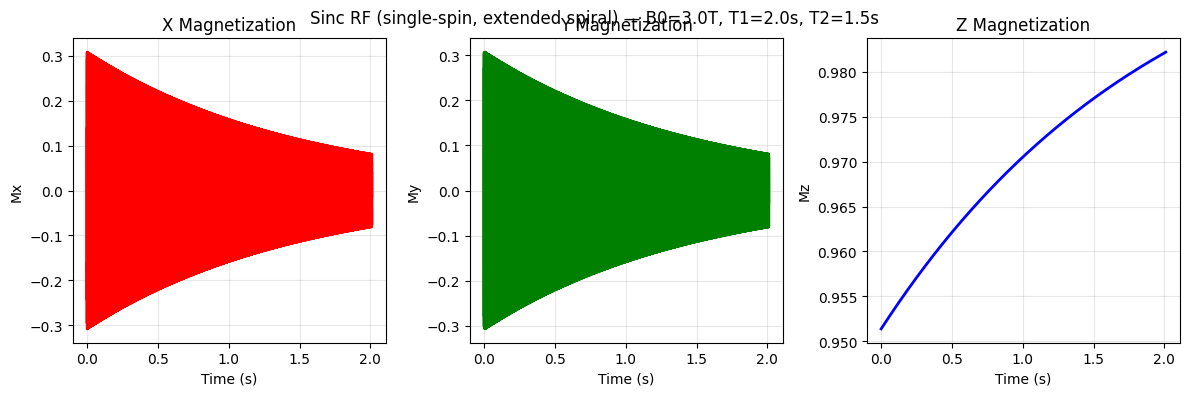

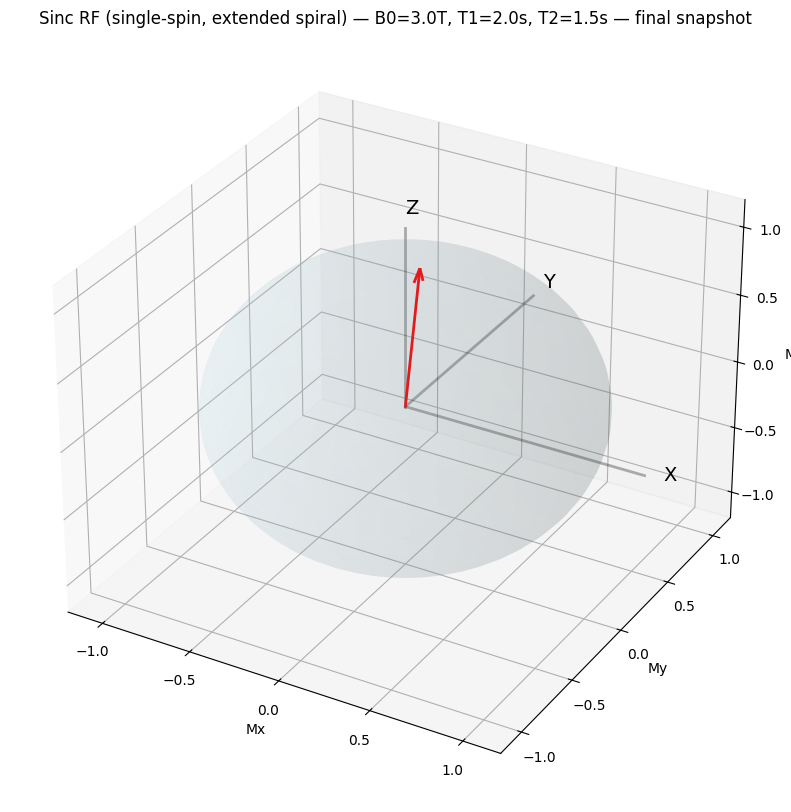

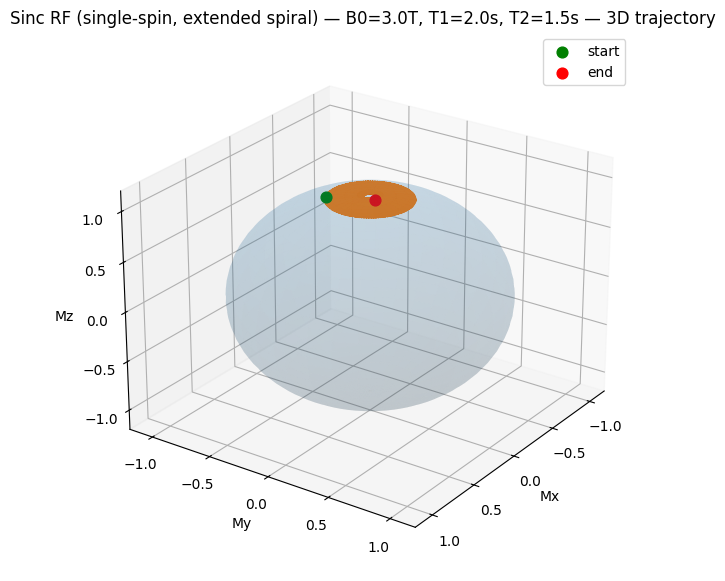

In [18]:
# Run the improved sinc_pulse_clean case to see many rotations with visible spiral decay
run_case("sinc_pulse_clean")

# You can also try other cases:
# run_case("mri_like")
# run_case("spin_echo")


## Dataset Generator

Uses blochsim generator to create datasets with train/val/test splits for training

In [19]:
# === Dataset creation & loader (adapted from `data/make_datasets.py` and `data/datasets.py`) ===
import json, math
import numpy as np
from tqdm.auto import tqdm

import sys
print(sys.executable)
import torch
from torch.utils.data import Dataset


def set_seed(seed: int) -> np.random.Generator:
    return np.random.default_rng(int(seed))


def draw_params(rng: np.random.Generator) -> dict:
    return dict(T1=float(rng.uniform(1.5, 4.0)), T2=float(rng.uniform(0.6, 2.0)), dB0=float(rng.uniform(-0.5, 0.5)), B0=float(rng.uniform(1.5, 3.0)), gamma=1.0)


def program_controls_and_run(
    sim,
    T: int,
    dt: float,
    rng: np.random.Generator,
    rf_families=("rect", "sinc", "gaussian", "windowed_sinc", "trapezoid"),
    p_easy: float = 0.8,   # 80% easy, 20% hard by default
):
    """
    Generate control sequence u[t] = [B1x, B1y, Gx, Gy] and run the simulation.
    Most cases are 'easy' (simple RF + no gradients), some are 'hard' (more exotic).
    """
    u = np.zeros((T, 4), dtype=np.float32)

    # Decide difficulty of this sample
    is_easy = rng.random() < p_easy

    # --- Choose RF parameters depending on difficulty ---
    phase = rng.uniform(0.0, 2.0 * math.pi)

    if is_easy:
        # Easier: smaller flip, moderate amplitude, simple RF types
        flip  = rng.uniform(math.radians(5), math.radians(60))
        B1amp = rng.uniform(2.0, 4.0)
        rf_type = rng.choice(["rect", "trapezoid"])

        # No gradients for easy cases
        sim.Gx = 0.0
        sim.Gy = 0.0
    else:
        # Harder: larger range of flip angles, amplitudes, and all RF families
        flip  = rng.uniform(math.radians(5), math.radians(150))
        B1amp = rng.uniform(1.0, 6.0)
        rf_type = rng.choice(rf_families)

        # Add non-zero gradients (tune ranges as you like)
        sim.Gx = rng.uniform(-0.03, 0.03)
        sim.Gy = rng.uniform(-0.03, 0.03)

    # --- Create RF pulse ---
    dispatch = {
        "rect":          lambda: sim.RF_pulse_rect(angle=flip, phase=phase, B1_amplitude=B1amp),
        "sinc":          lambda: sim.RF_pulse_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "gaussian":      lambda: sim.RF_pulse_gaussian(angle=flip, phase=phase, B1_amplitude=B1amp, sigma_frac=0.20),
        "windowed_sinc": lambda: sim.RF_pulse_windowed_sinc(angle=flip, phase=phase, B1_amplitude=B1amp, n_lobes=4),
        "trapezoid":     lambda: sim.RF_pulse_trapezoid(angle=flip, phase=phase, B1_amplitude=B1amp, ramp_frac=0.10),
    }

    dispatch[rf_type]()  # program the RF pulse in the simulator

    # --- Run the sequence while recording u(t) ---
    for t_idx in range(T):
        B1x = sim.B1 * math.cos(sim.B1_freq * sim.time - sim.phi1)
        B1y = -sim.B1 * math.sin(sim.B1_freq * sim.time - sim.phi1)
        u[t_idx, 0] = B1x
        u[t_idx, 1] = B1y
        u[t_idx, 2] = sim.Gx
        u[t_idx, 3] = sim.Gy
        sim.step(dt)

    return u, rf_type



def simulate_one(T: int, dt: float, rng: np.random.Generator, per_sample_t: bool = False, rf_families=('rect','sinc','gaussian','windowed_sinc','trapezoid')):
    p = draw_params(rng)
    # Use the BlochSimulator implementation defined earlier in this notebook
    sim = BlochSimulator(gamma=p['gamma'], B0=p['B0'])
    if rng.random() < 0.5:
        sim.setup_single_spin()
        sim.isochromats[0].dB0 = p['dB0']
        sim.isochromats[0].T1  = p['T1']
        sim.isochromats[0].T2  = p['T2']
    else:
        n = rng.integers(7, 17); spread = rng.uniform(0.1, 0.6)
        sim.setup_inhomogeneous(n_spins=int(n), spread=float(spread))
        for iso in sim.isochromats:
            iso.T1 = p['T1']; iso.T2 = p['T2']
    sim.reset()
    t = np.arange(T, dtype=np.float32) * float(dt)
    u, rf_type = program_controls_and_run(sim, T=T, dt=dt, rng=rng, rf_families=rf_families)
    y = np.array([np.sum(state['magnetization'], axis=0) for state in sim.history], dtype=np.float32)
    y0 = y[0].astype(np.float32)
    p_vec = np.array([p['T1'], p['T2'], p['dB0'], p['B0'], p['gamma']], dtype=np.float32)
    return dict(t=t, y=y, y0=y0, u=u, p=p_vec, rf_type=str(rf_type))


class BlochNPZ(Dataset):
    def __init__(self, path: str):
        data = np.load(path)
        self.y = torch.from_numpy(data['y']).float()
        self.y0 = torch.from_numpy(data['y0']).float()
        self.u = torch.from_numpy(data['u']).float()
        self.p = torch.from_numpy(data['p']).float()
        t_data = data['t']
        if t_data.ndim == 1:
            self.t = torch.from_numpy(t_data).float().unsqueeze(0).repeat(self.y.shape[0], 1)
        else:
            self.t = torch.from_numpy(t_data).float()
    def __len__(self): return self.y.shape[0]
    def __getitem__(self, idx):
        return { 't': self.t[idx], 'y': self.y[idx], 'y0': self.y0[idx], 'u': self.u[idx], 'p': self.p[idx] }


c:\Users\shore\AppData\Local\Programs\Python\Python312\python.exe


## Tested Neural Network Models

In [20]:
# === Models: GRU, RK4, PINN (from `models/`) ===
# NeuralBlochGRU (from models/neural_bloch_gru.py)
import torch
import torch.nn as nn

class NeuralBlochGRU(nn.Module):
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.hidden = hidden
        input_dim = 3 + 4 + 5 + 1
        self.inp = nn.Linear(input_dim, hidden)
        self.gru = nn.GRUCell(hidden, hidden)
        self.out = nn.Linear(hidden, 3)
        self.act = nn.SiLU()
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, y0, t, u, p):
        device = y0.device
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=device)
        y[:, 0] = y0
        t0 = t[0]
        tb0 = torch.full((B, 1), float(t0), device=device)
        x0 = torch.cat([y0, u[:, 0, :], p, tb0], dim=-1)
        h = self.act(self.inp(x0))
        for i in range(T - 1):
            t_n = t[i]
            tb = torch.full((B, 1), float(t_n), device=device)
            x = torch.cat([y[:, i, :], u[:, i, :], p, tb], dim=-1)
            x = self.act(self.inp(x))
            h = self.gru(x, h)
            y[:, i + 1, :] = self.out(self.act(h))
        return y

# NeuralBlochRK4 (lightweight) from models/neural_ode_rk4_fast.py
class ODEFunc(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(13, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 3))
        self._init_weights()
    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, t, y, u_t, p):
        t = torch.as_tensor(t, dtype=y.dtype, device=y.device)
        if t.ndim > 0:
            t = t[0]
        tb = torch.full((y.shape[0], 1), float(t), device=y.device)
        x = torch.cat([y, u_t, p, tb], dim=-1)
        return self.net(x)

class NeuralBlochRK4(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.func = ODEFunc(hidden=hidden)
    def _interp_linear_batch(self, t_grid, u_batch, tq):
        idx = torch.searchsorted(t_grid, tq).clamp(1, t_grid.numel()-1)
        t0, t1 = t_grid[idx-1], t_grid[idx]
        w = (tq - t0) / (t1 - t0 + 1e-12)
        u0, u1 = u_batch[:, idx-1, :], u_batch[:, idx, :]
        return (1-w)*u0 + w*u1
    def forward(self, y0, t, u, p):
        B, T, _ = u.shape
        y = torch.empty(B, T, 3, device=y0.device)
        y[:, 0] = y0
        h = t[1] - t[0]
        for i in range(T-1):
            t_n = t[i]
            y_n = y[:, i]
            u_n = self._interp_linear_batch(t, u, t_n)
            k1 = self.func(t_n, y_n, u_n, p)
            k2 = self.func(t_n + 0.5*h, y_n + 0.5*h*k1, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k3 = self.func(t_n + 0.5*h, y_n + 0.5*h*k2, self._interp_linear_batch(t, u, t_n + 0.5*h), p)
            k4 = self.func(t_n + h, y_n + h*k3, self._interp_linear_batch(t, u, t_n + h), p)
            y[:, i+1] = y_n + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        return y

# BlochPINN helper: MLP (extracted into its own cell for clarity)
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, depth=4):
        super().__init__()
        layers = []
        dim = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(dim, hidden))
            layers.append(nn.Tanh())
            dim = hidden
        layers.append(nn.Linear(dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# BlochPINN class (separate cell) including physics residual computation
import torch.autograd as autograd
class BlochPINN(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4):
        super().__init__()
        self.in_dim = 1 + 3 + 5 + 4
        self.out_dim = 3
        self.mlp = MLP(self.in_dim, self.out_dim, hidden=hidden, depth=depth)
    def _build_inputs(self, y0, t, u, p, require_grad_t: bool = False):
        device = y0.device
        B, T, _ = u.shape
        tBT = t.to(device).view(1, T, 1).expand(B, T, 1)
        y0BT = y0.view(B, 1, 3).expand(B, T, 3)
        pBT  = p.view(B, 1, 5).expand(B, T, 5)
        x = torch.cat([tBT, y0BT, pBT, u], dim=-1)
        x_flat = x.reshape(B * T, 13)
        return x_flat, (B, T)
    def forward(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        M_flat = self.mlp(x_flat)
        M = M_flat.view(B, T, 3)
        return M
    def bloch_rhs_flat(self, M_flat, u, p, shape_info):
        B, T = shape_info
        device = M_flat.device
        Mx = M_flat[:, 0]
        My = M_flat[:, 1]
        Mz = M_flat[:, 2]
        u_flat = u.view(B * T, 4).to(device)
        p_flat = p.view(B, 1, 5).expand(B, T, 5).reshape(B * T, 5).to(device)
        B1x   = u_flat[:, 0]
        B1y   = u_flat[:, 1]
        dB0   = p_flat[:, 2]
        B0    = p_flat[:, 3]
        gamma = p_flat[:, 4]
        Bx = B1x
        By = B1y
        Bz = B0 + dB0
        cx = My * Bz - Mz * By
        cy = Mz * Bx - Mx * Bz
        cz = Mx * By - My * Bx
        precess_x = gamma * cx
        precess_y = gamma * cy
        precess_z = gamma * cz
        T1 = p_flat[:, 0]
        T2 = p_flat[:, 1]
        M0 = torch.ones_like(Mz, device=device)
        relax_x = -Mx / T2
        relax_y = -My / T2
        relax_z = -(Mz - M0) / T1
        dMx = precess_x + relax_x
        dMy = precess_y + relax_y
        dMz = precess_z + relax_z
        dMdt_flat = torch.stack([dMx, dMy, dMz], dim=-1)
        return dMdt_flat
    def physics_residual(self, y0, t, u, p):
        x_flat, (B, T) = self._build_inputs(y0, t, u, p, require_grad_t=False)
        x_flat = x_flat.clone().detach().requires_grad_(True)
        M_flat = self.mlp(x_flat)
        dMdt_components = []
        for i in range(3):
            grad_full = autograd.grad(outputs=M_flat[:, i].sum(), inputs=x_flat, create_graph=True, retain_graph=True)[0]
            dMdt_i = grad_full[:, 0:1]
            dMdt_components.append(dMdt_i)
        dMdt_flat = torch.cat(dMdt_components, dim=-1)
        rhs_flat = self.bloch_rhs_flat(M_flat, u, p, (B, T))
        residual_flat = dMdt_flat - rhs_flat
        residual = residual_flat.view(B, T, 3)
        return residual


## Training Loop Code
Insert desired models into indicated locations

In [ ]:
# Training loop code 


from pathlib import Path
import csv

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def train_one_epoch(model, loader, t_shared, optimizer, criterion, device, epoch=None, total_epochs=None):
    model.train()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Train]", leave=False, ncols=90)
    for batch in pbar:
        # move to GPU/CPU
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]

        optimizer.zero_grad()
        yhat = model(y0, t_shared, u, p)  # (B,T,3)
        loss = criterion(yhat, y)        # scalar MSE over all components

        # Backprop + step
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate scalar loss (sum over elements)
        batch_elems = y.numel()  # B*T*3
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        # Per-component MSE accumulation
        diff2 = (yhat - y) ** 2          # (B,T,3)
        total_comp += diff2.sum(dim=(0, 1))  # sum over B,T -> (3,)

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    # Mean scalar loss over all elements
    mean_loss = total_loss / max(total_elems, 1)

    # Mean per-component loss over all elements (Mx, My, Mz)
    # Divide by number of (B*T) positions; each has 3 comps, so we normalize by B*T, not B*T*3
    # total_comp currently stores sum over B,T; shape (3,)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


@torch.no_grad()
def evaluate(model, loader, t_shared, criterion, device, epoch=None, total_epochs=None):
    model.eval()
    total_loss, total_elems = 0.0, 0
    total_comp = torch.zeros(3, device=device)  # Mx, My, Mz

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs} [Val]", leave=False, ncols=90)
    for batch in pbar:
        y, y0, u, p = [batch[k].to(device, non_blocking=True) for k in ("y", "y0", "u", "p")]
        yhat = model(y0, t_shared, u, p)
        loss = criterion(yhat, y)

        batch_elems = y.numel()
        total_loss += loss.item() * batch_elems
        total_elems += batch_elems

        diff2 = (yhat - y) ** 2
        total_comp += diff2.sum(dim=(0, 1))

        pbar.set_postfix({"batch_loss": f"{loss.item():.4e}"})

    mean_loss = total_loss / max(total_elems, 1)
    num_positions = total_elems / 3.0 if total_elems > 0 else 1.0
    mean_comp = total_comp / num_positions  # (3,)

    return mean_loss, mean_comp.detach().cpu()


def fit(
    model,
    train_loader,
    val_loader,
    t_shared,
    epochs=80,
    lr=1e-3,
    wd=1e-6,
    ckpt_path="checkpoints/best.pt",
    metrics_path=None,
    device="cpu",
    resume=False,
):
    """
    Train the model and optionally resume from an existing checkpoint.

    If resume=True and ckpt_path exists, this will:
      - load model weights
      - load optimizer state (if present)
      - restore best_val
      - resume from epoch = last_epoch + 1

    Otherwise, it trains from scratch.
    """
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    # Optional CSV logging setup
    metrics_file = None
    write_header = False
    if metrics_path is not None:
        metrics_file = Path(metrics_path)
        metrics_file.parent.mkdir(parents=True, exist_ok=True)
        write_header = not metrics_file.exists()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.MSELoss()

    best_val = float("inf")
    start_epoch = 0

    # --------- resume logic ----------
    if resume and ckpt_path.exists():
        print(f"[loop.fit] Resuming from checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
        if "optimizer" in ckpt:
            try:
                optimizer.load_state_dict(ckpt["optimizer"])
                print("[loop.fit] Loaded optimizer state from checkpoint.")
            except Exception as e:
                print(f"[loop.fit] Warning: could not load optimizer state: {e}")
        best_val = ckpt.get("val", float("inf"))
        last_epoch = ckpt.get("epoch", -1)
        start_epoch = last_epoch + 1
        print(f"[loop.fit] Last epoch in checkpoint: {last_epoch} → starting from epoch {start_epoch}")
    else:
        if resume:
            print(f"[loop.fit] No checkpoint found at {ckpt_path}, starting from scratch.")
        else:
            print("[loop.fit] Starting training from scratch.")

    # Main training loop
    epoch_bar = tqdm(range(start_epoch, epochs), desc="Training progress", ncols=100)
    for epoch in epoch_bar:
        tr, tr_comp = train_one_epoch(
            model, train_loader, t_shared, optimizer, criterion, device,
            epoch=epoch, total_epochs=epochs
        )
        va, va_comp = evaluate(
            model, val_loader, t_shared, criterion, device,
            epoch=epoch, total_epochs=epochs
        )

        # unpack per-component losses
        tr_Mx, tr_My, tr_Mz = tr_comp.tolist()
        va_Mx, va_My, va_Mz = va_comp.tolist()

        epoch_bar.set_postfix({
            "train": f"{tr:.4e}",
            "val":   f"{va:.4e}",
            "Mx":    f"{va_Mx:.2e}",
            "My":    f"{va_My:.2e}",
            "Mz":    f"{va_Mz:.2e}",
        })

        print(
            f"Epoch {epoch:03d} | "
            f"Train {tr:.6f} (Mx {tr_Mx:.3e}, My {tr_My:.3e}, Mz {tr_Mz:.3e}) | "
            f"Val {va:.6f} (Mx {va_Mx:.3e}, My {va_My:.3e}, Mz {va_Mz:.3e})"
        )

        # --- CSV logging (still only scalar losses, unless you want more columns) ---
        if metrics_file is not None:
            with metrics_file.open("a", newline="") as f:
                writer = csv.writer(f)
                if write_header:
                    writer.writerow(["epoch", "train_loss", "val_loss"])
                    write_header = False
                writer.writerow([epoch, tr, va])

        # --- save best checkpoint (still based on scalar val loss) ---
        if va < best_val:
            best_val = va
            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "val": va,
                    "epoch": epoch,
                },
                ckpt_path,
            )
            print(f"[loop.fit] Saved new best checkpoint at epoch {epoch} (val={va:.6e})")

